### Problem Statement
Based on the dataset named "mushroom_classification.csv", which includes various features of mushrooms to predict whether they are edible or poisonous. The dataset comprises the following columns:

- cap_diameter: The diameter of the mushroom cap.
- cap_shape: The shape of the mushroom cap, encoded as integers.
- gill_attachment: The attachment of the gills, encoded as integers.
- gill_color: The color of the gills, encoded as integers.
- stem_height: The height of the mushroom stem.
- stem_width The width of the mushroom stem.
- stem_color: The color of the mushroom stem, encoded as integers.
- season: The season when the mushroom was found, encoded as float.
- class: The classification of the mushroom, where 0 indicates edible and 1 indicates poisonous.
    
Task is to use this dataset to build and evaluate a binary classification model to classify mushrooms as edible or poisonous. You will start with basic models and gradually move towards advanced models like Gradient Boosting. Finally, you will explore various parameters of the Gradient Boosting model to enhance performance.

Dataset credits: Prisha Sawhney (https://www.kaggle.com/datasets/prishasawhney/mushroom-dataset/data)

**Import Necessary libraries**

In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report

### Data Preparation and Exploration

In [2]:
# Step 1: Import the data from the "mushroom_classification.csv" file and store it in a variable 'df'
df = pd.read_csv("mushroom_classification.csv")

# Step 2: Display the number of rows and columns in the dataset
print("Number of rows and columns in the dataset:", df.shape)

# Step 3: Display the first few rows of the dataset to get an overview
print("First few rows of the dataset:")
df.head()

Number of rows and columns in the dataset: (54035, 9)
First few rows of the dataset:


,cap_diameter,cap_shape,gill_attachment,gill_color,stem_height,stem_width,stem_color,season,class
0,1372,2,2,10,3.807467,1545,11,1.804273,1
1,1461,2,2,10,3.807467,1557,11,1.804273,1
2,1371,2,2,10,3.612496,1566,11,1.804273,1
3,1261,6,2,10,3.787572,1566,11,1.804273,1
4,1305,6,2,10,3.711971,1464,11,0.943195,1


### Exploratory data analysis

In [3]:
# Step 1: Perform a group-by operation on the target class and calculate the mean of specific features
features_to_analyze = ["cap_diameter", "stem_height", "stem_width"]
grouped = df.groupby('class')[features_to_analyze].mean()
print("Grouped by target class:")
print(grouped)

Grouped by target class:
       cap_diameter  stem_height   stem_width
class                                        
0        633.064696     0.627374  1208.915189
1        513.236293     0.867251   921.516563


<Figure size 1200x800 with 0 Axes>

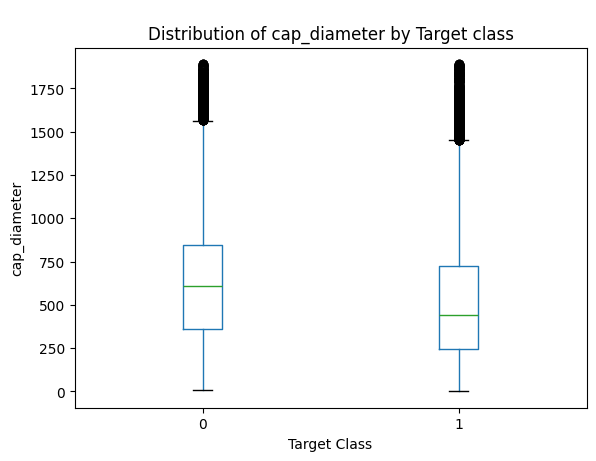

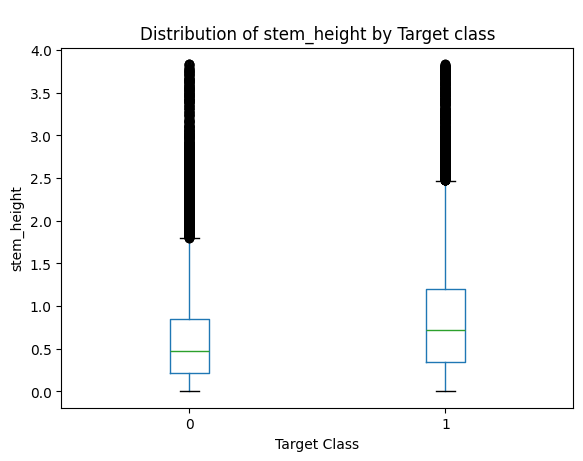

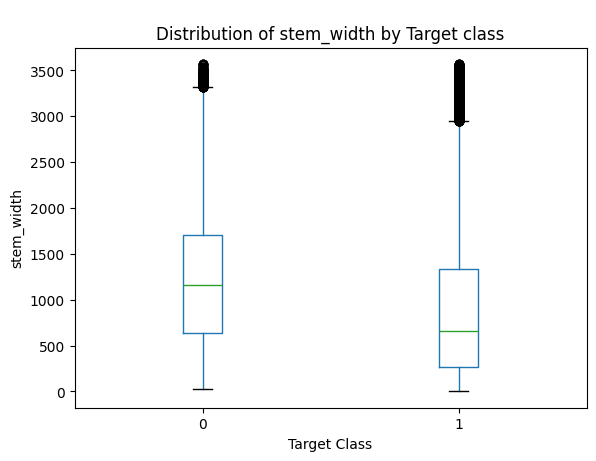

In [4]:
# Step 2: Visualize the distribution of these features using box plots
plt.figure(figsize=(12, 8))
for feature in features_to_analyze:
    df.boxplot(column=feature, by='class', grid=False)
    plt.title(f'Distribution of {feature} by Target class')
    plt.suptitle(' ')
    plt.xlabel('Target Class')
    plt.ylabel(feature)
    plt.show()

### Model Training Using Logistic Regression

In [5]:
# Step 1: Select the features and target variable for modeling
X = df[["cap_diameter", "cap_shape", "gill_attachment", "gill_color", "stem_height", "stem_width", "stem_color", "season"]]
y = df["class"]

# Step 2: Split the data into training and test sets with a test size of 25%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=10)

In [6]:
# Step 3: Initialize and train a Logistic Regression model using training data
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

# Step 4: Make predictions on the test set using the trained model
y_pred_lr = lr_model.predict(X_test)

# Step 5: Evaluate the model using a classification report and print
report_lr = classification_report(y_test, y_pred_lr)
print("Logistic Regression Classification Report:")
print(report_lr)

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.55      0.57      6087
           1       0.65      0.67      0.66      7422

    accuracy                           0.62     13509
   macro avg       0.61      0.61      0.61     13509
weighted avg       0.62      0.62      0.62     13509



### Model Training Using Decision Tree Classifier

In [7]:
# Step 1: Initialize and train a Decision Tree Classifier model using the training data
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

# Step 2: Make predictions on the test set using the trained model
y_pred_dt = dt_model.predict(X_test)

# Step 3: Evaluate the model using a classification report and print the report
report_dt = classification_report(y_test, y_pred_dt)
print("Decision Tree Classification Report:")
print(report_dt)

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      6087
           1       0.98      0.98      0.98      7422

    accuracy                           0.98     13509
   macro avg       0.98      0.97      0.98     13509
weighted avg       0.98      0.98      0.98     13509



### Model Training Using Gradient Boosting Classifier

In [8]:
# Step 1: Initialize and train a Gradient Boosting Classifier model using the training data
gb_model = GradientBoostingClassifier()
gb_model.fit(X_train, y_train)

# Step 2: Make predictions on the test set using the trained model
y_pred_gb = gb_model.predict(X_test)

# Step 3: Evaluate the model using the classification report and print the report
report_gb = classification_report(y_test, y_pred_gb)
print("Gradient Boosting Classification Report:")
print(report_gb)

Gradient Boosting Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.88      0.87      6087
           1       0.90      0.89      0.89      7422

    accuracy                           0.88     13509
   macro avg       0.88      0.88      0.88     13509
weighted avg       0.88      0.88      0.88     13509



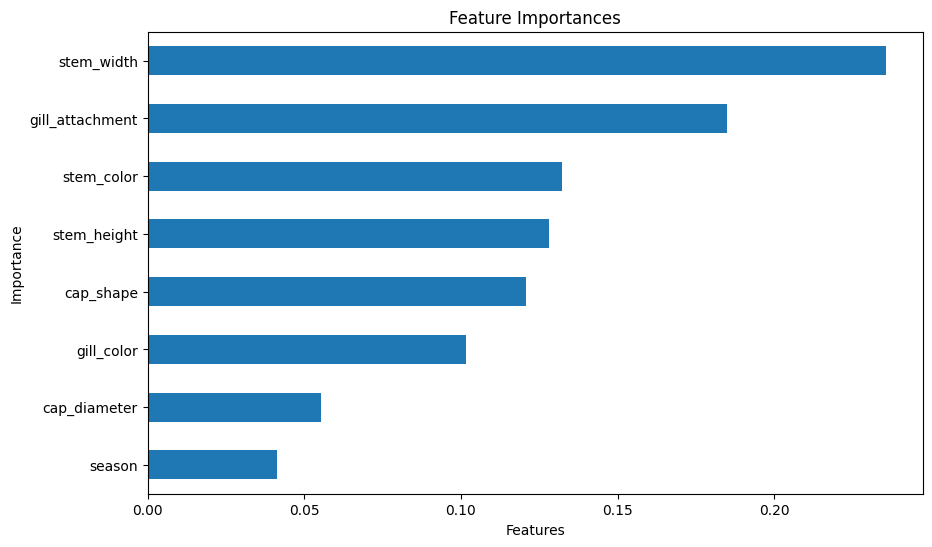

In [9]:
# Step 4: Calculate and display the feature importance
feature_importances = pd.Series(gb_model.feature_importances_, index=X.columns)
feature_importances.sort_values().plot(kind='barh', figsize=(10, 6))
plt.title("Feature Importances")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

### Model Training Using Gradient Boosting Classifier with specified parameters

In [10]:
# Step 1: Train a Gradient Boosting Model with specified parameters
gb_params = {
    'learning_rate':0.05,
    'n_estimators':150,
    'max_depth':4,
    'min_samples_split':3,
    'min_samples_leaf':2
}
gb_model_custom = GradientBoostingClassifier(**gb_params)
gb_model_custom.fit(X_train, y_train)

# Step 2: Make prediction on the test set using trained model
y_pred_gb_custom = gb_model_custom.predict(X_test)

# Step 3: Evaluate the model using classification report and print it
report_gb_custom = classification_report(y_test, y_pred_gb_custom)
print("Gradient Boosting Classification Report with Custom parameters:")
print(report_gb_custom)

Gradient Boosting Classification Report with Custom parameters:
              precision    recall  f1-score   support

           0       0.88      0.91      0.90      6087
           1       0.93      0.90      0.91      7422

    accuracy                           0.90     13509
   macro avg       0.90      0.90      0.90     13509
weighted avg       0.91      0.90      0.90     13509



### Conclusion

We built and evaluated machine learning models as edible or poisonous. Here are key findings:
1. Logistic Regression:
   - Accuracy: 0.62
   - Logistic Regression model provides a basic level of performance.
<br></br>
2. Decision Tree Classifier:
   - Accuracy: 0.98
   - Decision Tree Classifier showed significant improvement with an accuracy of 0.98.
<br></br>
3. Gradient Boosting Classifier:
   - Accuracy with default parameters: 0.88
   - Accuracy with custom parameters: 0.90
   - The Gradient Boosting Classifier achieved an accuracy of 0.88 with default parameters and improved to 0.90 with custom parameters.
<br></br>
Overall the Decision Tree Classifier and Gradient Boosting Classifier with custom parameters both demonstrated strong performance, with Gradient Boosting model showing slight improvement with parameter tuning.